Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully
Total Sentences Loaded: 12544
Sentence:
Al - Zaman : American forces killed Shaikh Abdullah al - Ani , the preacher at the mosque in the town of Qaim , near the Syrian border .

Gold Heads:
[0, 3, 1, 7, 6, 7, 1, 7, 8, 8, 12, 8, 15, 15, 8, 18, 18, 15, 21, 21, 18, 23, 21, 28, 28, 28, 28, 21, 1]

BERT Tokens:
['[CLS]', 'al', '-', 'za', '##man', ':', 'american', 'forces', 'killed', 'sha', '##ikh', 'abdullah', 'al', '-', 'an', '##i', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'q', '##ai', '##m', ',', 'near', 'the', 'syrian', 'border', '.', '[SEP]']


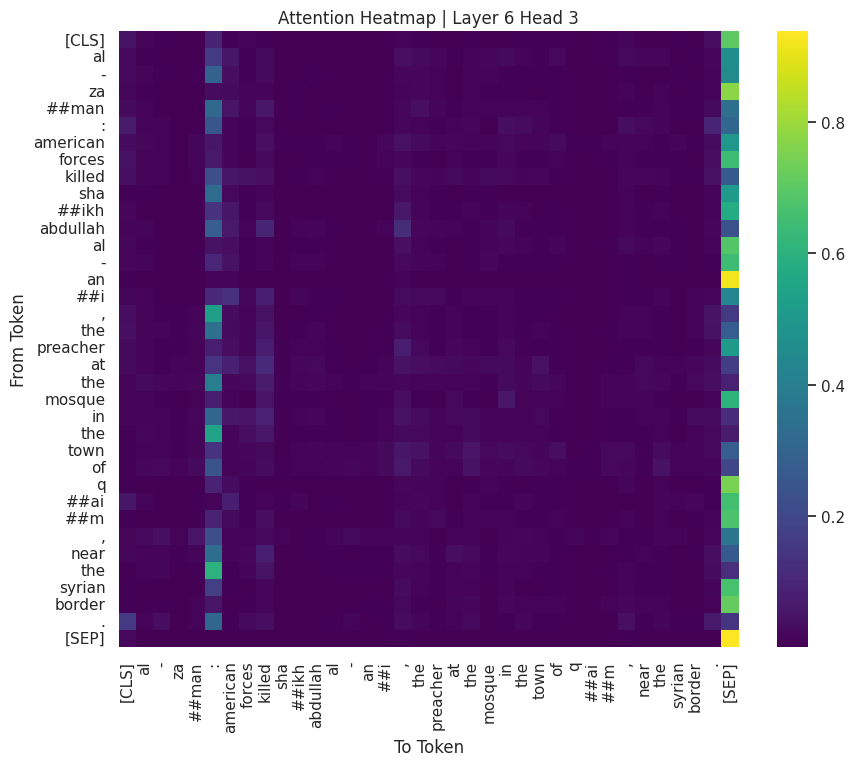


Top heads for this sentence:
    Layer  Head  Accuracy
33      3    10  0.321429
24      3     1  0.321429
10      1    11  0.285714
69      6    10  0.285714
94      8    11  0.250000
13      2     2  0.250000
8       1     9  0.214286
45      4    10  0.214286
60      6     1  0.178571
59      5    12  0.178571


100%|██████████| 2000/2000 [00:36<00:00, 55.47it/s]



Top Overall Grammar Heads:
    Layer  Head  Accuracy
33      3    10  0.269969
24      3     1  0.269969
10      1    11  0.267264
69      6    10  0.246162
45      4    10  0.240784
13      2     2  0.198233
94      8    11  0.166693
46      4    11  0.156476
8       1     9  0.145432
53      5     6  0.137217
77      7     6  0.125618
59      5    12  0.124106
3       1     4  0.123368
1       1     2  0.118692
41      4     6  0.105154


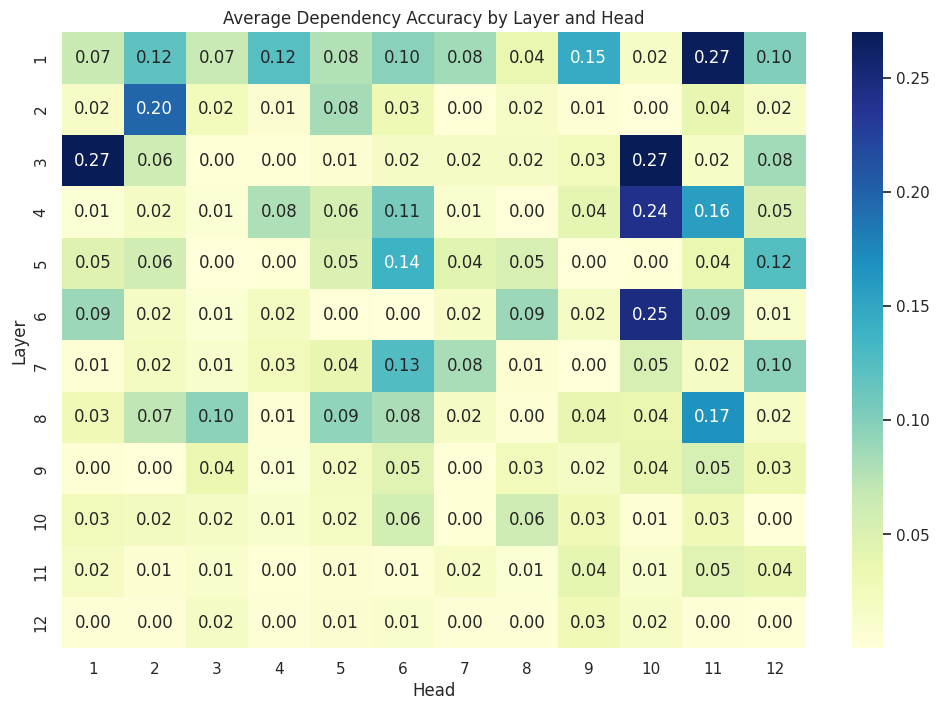

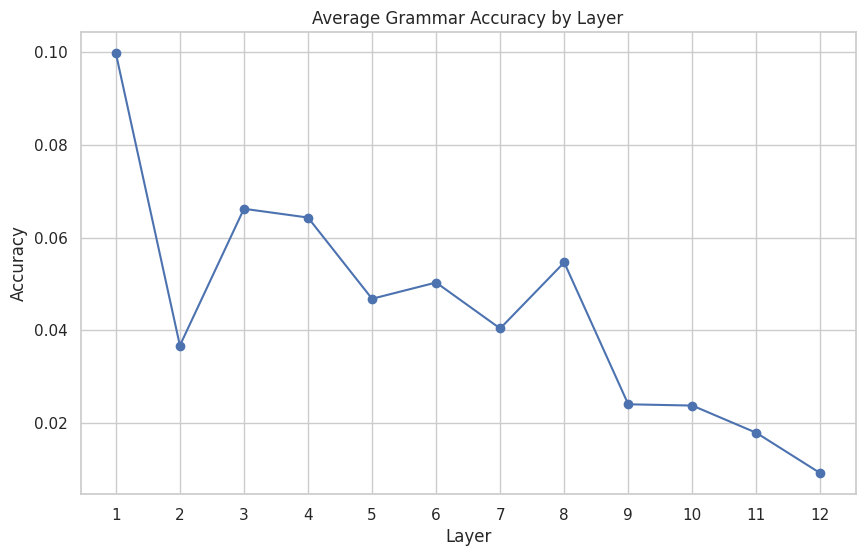


BEST HEAD FOUND:
Layer        3.000000
Head        10.000000
Accuracy     0.269969
Name: 33, dtype: float64

Saved file: bert_ud_results.csv

Project Interpretation:

1. Higher accuracy means that attention head aligns with dependency grammar.
2. Compare layers:
   - Early layers = lexical / POS
   - Middle layers = syntax
   - Later layers = semantics
3. If middle layers score highest, it supports grammar emergence.



In [1]:

# COLAB FULL PROJECT PIPELINE

!pip -q install transformers datasets torch seaborn matplotlib pandas numpy


import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from tqdm import tqdm

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

model.to(device)
model.eval()

print("BERT loaded successfully")


!pip -q install conllu requests

import requests
from conllu import parse


url = "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu"

data = requests.get(url).text

sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))




def clean_sentence(tokens):
    """
    Convert token list to sentence text
    """
    return " ".join(tokens)


def get_model_attention(sentence):
    """
    Run sentence through BERT and return attentions + tokens
    """
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions
    token_ids = inputs["input_ids"][0]
    bert_tokens = tokenizer.convert_ids_to_tokens(token_ids)

    return attentions, bert_tokens


def dependency_pairs(heads):
    """
    Convert head list into child-parent pairs
    Example: [2,3,0,3]
    Returns [(1,2),(2,3),(4,3)]
    """
    pairs = []

    for child_idx, parent_idx in enumerate(heads, start=1):
        if parent_idx != 0:
            pairs.append((child_idx, parent_idx))

    return pairs


def score_attention_head(attn_matrix, gold_heads):
    """
    Compare attention with gold dependency heads
    child predicts parent using argmax
    """
    correct = 0
    total = 0

    for child_idx, parent_idx in enumerate(gold_heads, start=1):

        if parent_idx == 0:
            continue


        pred = np.argmax(attn_matrix[child_idx])

        if pred == parent_idx:
            correct += 1

        total += 1

    if total == 0:
        return 0

    return correct / total


def visualize_attention(attentions, bert_tokens, layer=6, head=0):
    """
    Plot one attention head heatmap
    """
    matrix = attentions[layer][0, head].cpu().numpy()

    plt.figure(figsize=(10,8))
    sns.heatmap(
        matrix,
        xticklabels=bert_tokens,
        yticklabels=bert_tokens,
        cmap="viridis"
    )

    plt.title(f"Attention Heatmap | Layer {layer+1} Head {head+1}")
    plt.xlabel("To Token")
    plt.ylabel("From Token")
    plt.show()



sample = sentences[0]

words = [token["form"] for token in sample]
heads = [token["head"] for token in sample]

sentence = clean_sentence(words)

print("Sentence:")
print(sentence)

print("\nGold Heads:")
print(heads)

attentions, bert_tokens = get_model_attention(sentence)

print("\nBERT Tokens:")
print(bert_tokens)


visualize_attention(attentions, bert_tokens, layer=5, head=2)


results = []

for layer in range(12):
    for head in range(12):

        matrix = attentions[layer][0, head].cpu().numpy()

        acc = score_attention_head(matrix, heads)

        results.append([layer+1, head+1, acc])

df_one = pd.DataFrame(results, columns=["Layer", "Head", "Accuracy"])

print("\nTop heads for this sentence:")
print(df_one.sort_values("Accuracy", ascending=False).head(10))


NUM_SENTENCES = 2000

all_scores = []

for idx in tqdm(range(NUM_SENTENCES)):

    try:
        sample = sentences[idx]

        words = [token["form"] for token in sample]
        heads = [token["head"] for token in sample]


        if len(words) > 30:
            continue

        sentence = clean_sentence(words)

        attentions, bert_tokens = get_model_attention(sentence)


        if len(bert_tokens) > 60:
            continue

        for layer in range(12):
            for head in range(12):

                matrix = attentions[layer][0, head].cpu().numpy()

                acc = score_attention_head(matrix, heads)

                all_scores.append([layer+1, head+1, acc])

    except:
        continue


df = pd.DataFrame(all_scores, columns=["Layer", "Head", "Accuracy"])

avg_df = (
    df.groupby(["Layer", "Head"])["Accuracy"]
    .mean()
    .reset_index()
)

print("\nTop Overall Grammar Heads:")
print(avg_df.sort_values("Accuracy", ascending=False).head(15))


pivot = avg_df.pivot(index="Layer", columns="Head", values="Accuracy")

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Dependency Accuracy by Layer and Head")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.show()


layer_avg = (
    avg_df.groupby("Layer")["Accuracy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
plt.plot(layer_avg["Layer"], layer_avg["Accuracy"], marker="o")
plt.title("Average Grammar Accuracy by Layer")
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.xticks(range(1,13))
plt.show()


best = avg_df.sort_values("Accuracy", ascending=False).iloc[0]

print("\nBEST HEAD FOUND:")
print(best)


avg_df.to_csv("bert_ud_results.csv", index=False)

print("\nSaved file: bert_ud_results.csv")


print("\nProject Interpretation:")
print("""
1. Higher accuracy means that attention head aligns with dependency grammar.
2. Compare layers:
   - Early layers = lexical / POS
   - Middle layers = syntax
   - Later layers = semantics
3. If middle layers score highest, it supports grammar emergence.
""")